<a href="https://colab.research.google.com/github/Ridhafathimaa/global-youtube-statistics-2023/blob/main/youtube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape:
(995, 28)

First 5 Rows:
   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...          

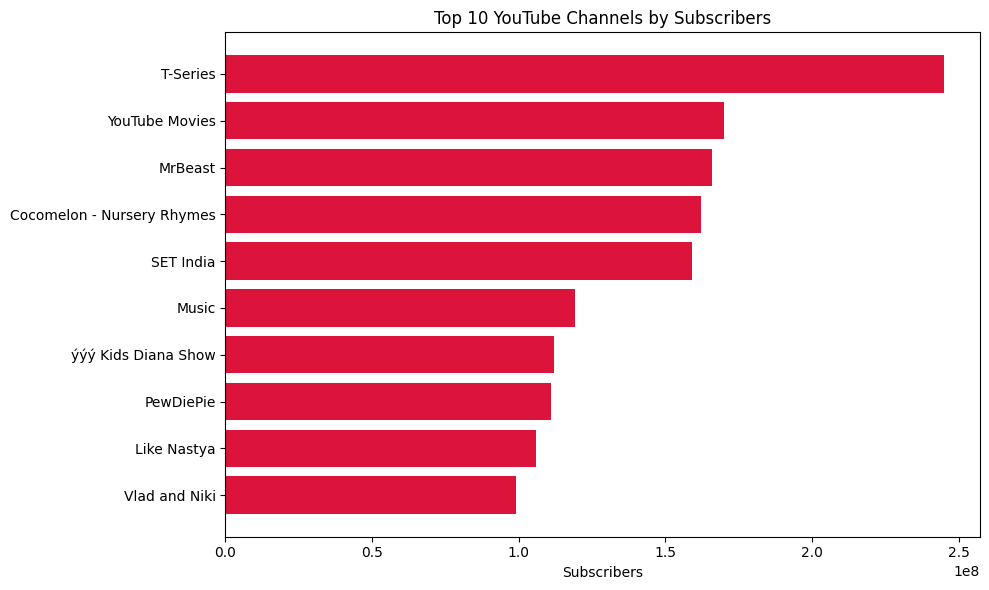

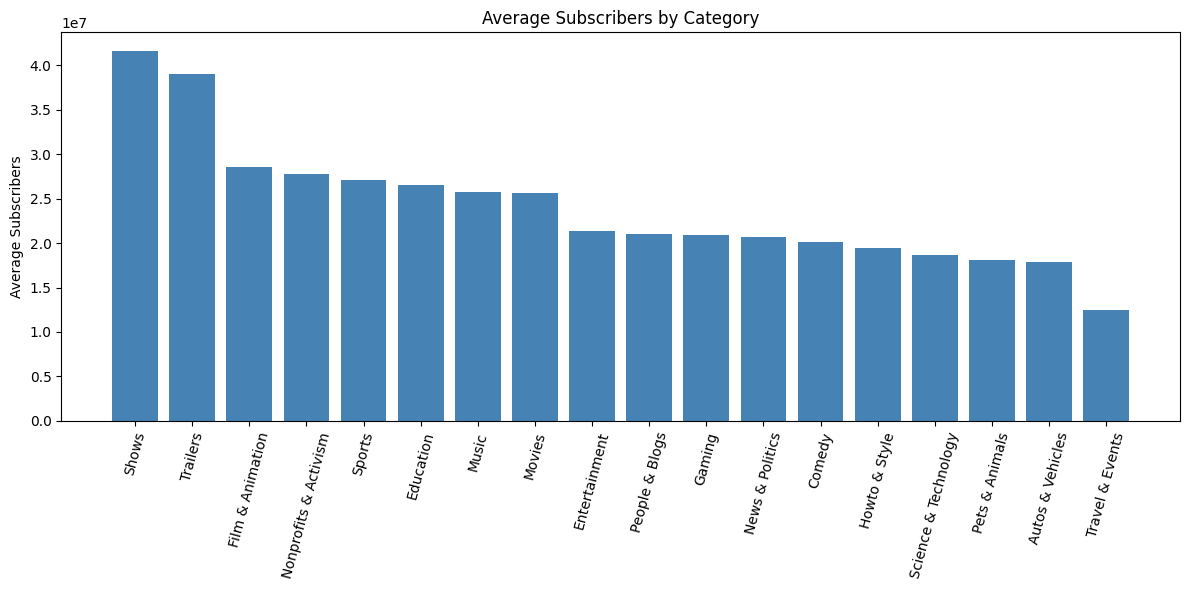

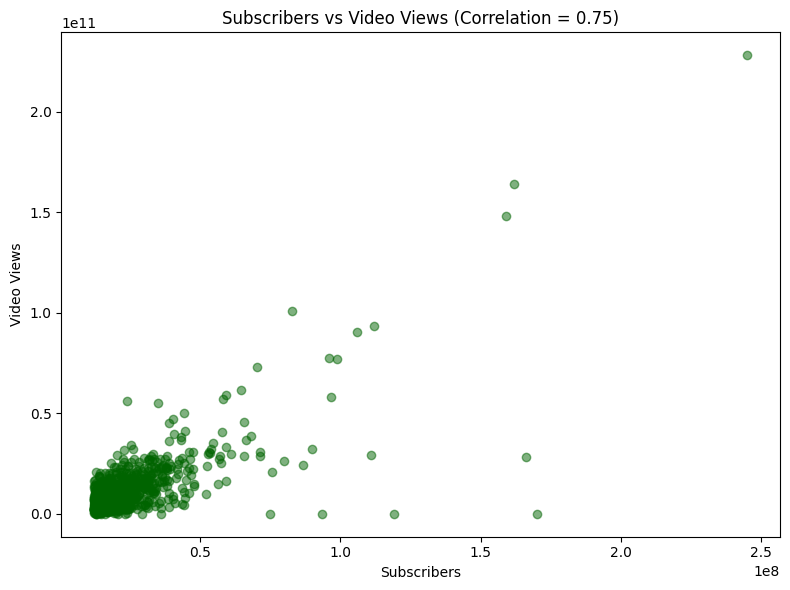

In [13]:
# ============================================
# Project 5: Global YouTube Statistics 2023
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Question 1: Load dataset and clean column names


df = pd.read_csv("Global YouTube Statistics.csv", encoding="latin1")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nOriginal Column Names:")
print(df.columns.tolist())

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("[^a-z0-9_]", "", regex=True)
)

print("\nCleaned Column Names:")
print(df.columns.tolist())



# Question 2: Handle missing values in numeric columns

print("\nMissing Values Before Filling:")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Filling:")
print(df[numeric_cols].isnull().sum())



# Question 3: Find Top 10 channels by subscribers


top10_subs = df.sort_values("subscribers", ascending=False).head(10)

print("\nTop 10 YouTube Channels by Subscribers")
print(top10_subs[["youtuber", "subscribers", "category", "country"]])



# Question 4: Group by category to find average
# subscribers and video views


category_avg = (
    df.groupby("category")[["subscribers", "video_views"]]
    .mean()
    .sort_values("subscribers", ascending=False)
)

print("\nAverage Subscribers and Views by Category")
print(category_avg)



# Question 5: Calculate total and average earnings
# using NumPy


df["avg_yearly_earnings"] = (
    df["lowest_yearly_earnings"] +
    df["highest_yearly_earnings"]
) / 2

total_earnings = np.sum(df["avg_yearly_earnings"])
average_earnings = np.mean(df["avg_yearly_earnings"])

print(f"\nTotal Earnings: ${total_earnings:,.2f}")
print(f"Average Earnings: ${average_earnings:,.2f}")


# Question 6: Find correlation between subscribers
# and video views


correlation = df["subscribers"].corr(df["video_views"])

print(f"\nCorrelation between Subscribers and Video Views: {correlation:.3f}")



# Question 7: Visualizations


# (a) Horizontal Bar Chart - Top 10 Channels

plt.figure(figsize=(10,6))
plt.barh(top10_subs["youtuber"], top10_subs["subscribers"], color="crimson")
plt.xlabel("Subscribers")
plt.title("Top 10 YouTube Channels by Subscribers")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# (b) Bar Chart - Average Subscribers by Category

plt.figure(figsize=(12,6))
plt.bar(category_avg.index, category_avg["subscribers"], color="steelblue")
plt.xticks(rotation=75)
plt.ylabel("Average Subscribers")
plt.title("Average Subscribers by Category")
plt.tight_layout()
plt.show()


# (c) Scatter Plot - Subscribers vs Video Views

plt.figure(figsize=(8,6))
plt.scatter(df["subscribers"], df["video_views"], alpha=0.5, color="darkgreen")
plt.xlabel("Subscribers")
plt.ylabel("Video Views")
plt.title(f"Subscribers vs Video Views (Correlation = {correlation:.2f})")
plt.tight_layout()
plt.show()